<a href="https://colab.research.google.com/github/YiruiLi2004/MSSP6070/blob/main/Assignments/Assignment%201/Assignment_1_yiruili.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1: Academic Performance Analysis
This notebook analyzes global assessment scores (`G_SC`) by parental education, socioeconomic group/stratum, gender, academic program, school background, and access to home technology resources.


In [111]:
import os
import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import f_oneway, ttest_ind

repo_url = "https://github.com/YiruiLi2004/MSSP6070.git"
repo_path = "/content/MSSP6070"

# Clone the repository, or update it if it already exists
if not os.path.exists(repo_path):
    subprocess.run(["git", "clone", repo_url], check=True)
else:
    subprocess.run(["git", "-C", repo_path, "pull"], check=True)

# Work from the repository root
os.chdir(repo_path)

# Load the dataset from the data folder
df = pd.read_csv("data/data_academic_performance 2.csv")

df.head()

,COD_S11,GENDER,EDU_FATHER,EDU_MOTHER,OCC_FATHER,OCC_MOTHER,STRATUM,SISBEN,PEOPLE_HOUSE,Unnamed: 9,...,CC_PRO,ENG_PRO,WC_PRO,FEP_PRO,G_SC,PERCENTILE,2ND_DECILE,QUARTILE,SEL,SEL_IHE
0,SB11201210000129,F,Incomplete Professional Education,Complete technique or technology,Technical or professional level employee,Home,Stratum 4,It is not classified by the SISBEN,Three,NaN,...,71,93,79,181,180,91,5,4,2,2
1,SB11201210000137,F,Complete Secundary,Complete professional education,Entrepreneur,Independent professional,Stratum 5,It is not classified by the SISBEN,Three,NaN,...,86,98,78,201,182,92,5,4,4,4
2,SB11201210005154,M,Not sure,Not sure,Independent,Home,Stratum 2,Level 2,Five,NaN,...,18,43,22,113,113,7,1,1,1,1
3,SB11201210007504,F,Not sure,Not sure,Other occupation,Independent,Stratum 2,It is not classified by the SISBEN,Three,NaN,...,76,80,48,137,157,67,4,3,2,2
4,SB11201210007548,M,Complete professional education,Complete professional education,Executive,Home,Stratum 4,It is not classified by the SISBEN,One,NaN,...,98,100,71,189,198,98,5,4,4,2


## 1. Data Preparation and Quality Check


In [112]:
# Check basic data quality
print("Dataset shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate student IDs:", df["COD_S11"].duplicated().sum())

missing_values = df.isnull().sum()
print("\nColumns with missing values:")
print(missing_values[missing_values > 0])

print("\nColumn types:")
print(df.dtypes.value_counts())

Dataset shape: (12411, 45)
Duplicate rows: 0
Duplicate student IDs: 0

Columns with missing values:
Unnamed: 9    12411
dtype: int64

Column types:
object     27
int64      17
float64     1
Name: count, dtype: int64


In [113]:
# Remove the completely empty column and extra spaces in text categories
df = df.drop(columns=["Unnamed: 9"])
for column in df.select_dtypes(include="object").columns:
    df[column] = df[column].str.strip()

print("Shape after cleaning:", df.shape)
print("Remaining missing values:", df.isnull().sum().sum())


Shape after cleaning: (12411, 44)
Remaining missing values: 0


The original file contains 12,411 student records. There are no duplicate rows or duplicate student IDs. `Unnamed: 9` is completely empty and was removed, and extra spaces were stripped from text categories. After cleaning, the dataset has 44 variables and no missing values recognized by pandas. Some responses such as `0`, `Not sure`, and `Ninguno` are still ambiguous, so they are handled separately in the comparisons below.


## 2. Descriptive Statistics Summary


### 2.1 Numerical Variables


In [114]:
# Descriptive statistics for the main academic score variables
score_columns = ["MAT_S11", "CR_S11", "CC_S11", "BIO_S11", "ENG_S11",
                 "QR_PRO", "CR_PRO", "CC_PRO", "ENG_PRO", "WC_PRO", "G_SC"]

descriptive_summary = pd.DataFrame({
    "N": df[score_columns].count(),
    "Mean": df[score_columns].mean(),
    "Median": df[score_columns].median(),
    "SD": df[score_columns].std(),
    "Min": df[score_columns].min(),
    "Max": df[score_columns].max(),
    "IQR": df[score_columns].quantile(0.75) - df[score_columns].quantile(0.25),
    "Skewness": df[score_columns].skew()
}).round(2)

descriptive_summary


,N,Mean,Median,SD,Min,Max,IQR,Skewness
MAT_S11,12411,64.32,64.0,11.87,26,100,16.0,0.40
CR_S11,12411,60.78,61.0,10.03,24,100,13.0,0.21
CC_S11,12411,60.71,60.0,10.12,0,100,13.0,0.35
BIO_S11,12411,63.95,64.0,11.16,11,100,15.0,0.30
ENG_S11,12411,61.80,59.0,14.30,26,100,22.0,0.61
QR_PRO,12411,77.42,85.0,22.67,1,100,31.0,-1.18
CR_PRO,12411,62.20,67.0,27.67,1,100,44.0,-0.52
CC_PRO,12411,59.19,65.0,28.99,1,100,49.0,-0.42
ENG_PRO,12411,67.50,74.0,25.50,1,100,37.0,-0.80
WC_PRO,12411,53.70,56.0,30.00,0,100,52.0,-0.18


The descriptive statistics give a first view of the center and spread of the academic scores. For the main outcome, the Saber PRO Global Score has a mean of 162.71 and a median of 163. The following sections compare these outcomes across student groups rather than relying on the overall average alone.


### 2.2 Categorical Variables


In [115]:
# Counts and percentages for the main categorical variables
categorical_vars = ["GENDER", "EDU_FATHER", "EDU_MOTHER", "STRATUM", "SISBEN",
                    "SCHOOL_NAT", "SCHOOL_TYPE", "ACADEMIC_PROGRAM", "INTERNET", "COMPUTER"]

for variable in categorical_vars:
    summary = pd.DataFrame({
        "Count": df[variable].value_counts(),
        "Percent": df[variable].value_counts(normalize=True).mul(100).round(2)
    })
    print(f"\n{variable}")
    display(summary)



GENDER


,Count,Percent
GENDER,,
M,7368,59.37
F,5043,40.63



EDU_FATHER


,Count,Percent
EDU_FATHER,,
Complete professional education,3016,24.30
Complete Secundary,2843,22.91
Complete technique or technology,1194,9.62
Incomplete Secundary,1091,8.79
Postgraduate education,1085,8.74
Complete primary,824,6.64
Incomplete primary,735,5.92
Incomplete Professional Education,425,3.42
Not sure,407,3.28



EDU_MOTHER


...

,Count,Percent
ACADEMIC_PROGRAM,,
INDUSTRIAL ENGINEERING,5318,42.85
CIVIL ENGINEERING,3320,26.75
MECHANICAL ENGINEERING,1135,9.15
CHEMICAL ENGINEERING,1000,8.06
ELECTRONIC ENGINEERING,849,6.84
ELECTRIC ENGINEERING,278,2.24
MECHATRONICS ENGINEERING,82,0.66
CATASTRAL ENGINEERING AND GEODESY,78,0.63
PRODUCTION ENGINEERING,60,0.48



INTERNET


,Count,Percent
INTERNET,,
Yes,9752,78.58
No,2659,21.42



COMPUTER


,Count,Percent
COMPUTER,,
Yes,10174,81.98
No,2237,18.02


### 2.3 Distribution of the Main Outcome


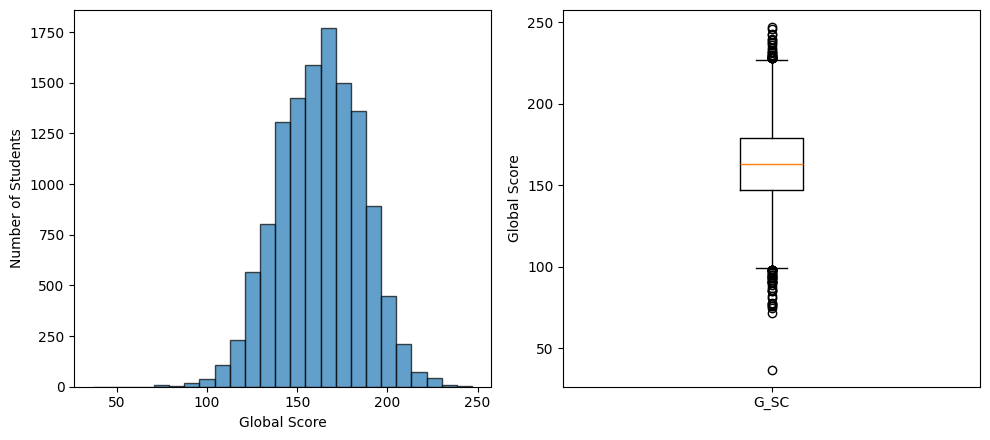

In [116]:
# Distribution of the Saber PRO Global Score

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

# Histogram
axes[0].hist(df["G_SC"], bins=25, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Global Score")
axes[0].set_ylabel("Number of Students")

# Boxplot
axes[1].boxplot(df["G_SC"], vert=True)
axes[1].set_ylabel("Global Score")
axes[1].set_xticks([1])
axes[1].set_xticklabels(["G_SC"])

plt.tight_layout()
plt.show()


The Global Score distribution is roughly bell-shaped and close to a normal distribution. The mean (162.71) and median (163) are very similar, suggesting that the distribution is fairly symmetric. There are still a few unusually low scores, so it is not perfectly normal.


The descriptive checks also helped guide the later analysis. The dataset has no remaining missing values after removing the empty column, but several categorical responses are ambiguous and require separate handling. Group sizes are also uneven, especially across academic programs and socioeconomic categories, so counts are reported together with group statistics and very small program groups are excluded from the main comparison. The Global Score is roughly bell-shaped, so no transformation is applied. Unusually low or high scores are retained because there is no evidence that they are data errors.

## 3. Group Comparisons and Further Analysis


### 3.1 Parental Education
**Question:** Does parental education influence outcomes, and if so, how much?


In [117]:
# Summarize global score by father's and mother's education
father_edu = df.groupby("EDU_FATHER")["G_SC"].agg(["count", "mean", "median", "std"])
mother_edu = df.groupby("EDU_MOTHER")["G_SC"].agg(["count", "mean", "median", "std"])

print("Father's education:")
display(father_edu.sort_values("mean", ascending=False))
print("Mother's education:")
display(mother_edu.sort_values("mean", ascending=False))


Father's education:


,count,mean,median,std
EDU_FATHER,,,,
Postgraduate education,1085,176.985253,179.0,21.734132
Complete professional education,3016,167.765915,169.0,23.030089
Incomplete Professional Education,425,166.917647,168.0,22.685198
Complete technique or technology,1194,164.033501,164.0,22.165359
Incomplete technical or technological,277,162.101083,162.0,21.881198
Not sure,407,160.294840,159.0,22.939555
Complete Secundary,2843,158.785790,159.0,22.114288
Ninguno,123,156.634146,159.0,23.188560
Incomplete Secundary,1091,156.535289,157.0,21.736989


Mother's education:


,count,mean,median,std
EDU_MOTHER,,,,
Postgraduate education,997,175.636911,178.0,22.119758
Complete professional education,3059,168.845374,170.0,22.978321
Incomplete Professional Education,502,166.685259,168.0,22.931830
Complete technique or technology,1495,163.242140,163.0,21.943495
Incomplete technical or technological,341,161.879765,164.0,20.744388
Not sure,179,159.407821,159.0,25.469659
Complete Secundary,3106,158.470702,159.0,21.949597
Incomplete Secundary,1056,155.672348,156.0,21.928635
Complete primary,713,155.336606,155.0,22.012293


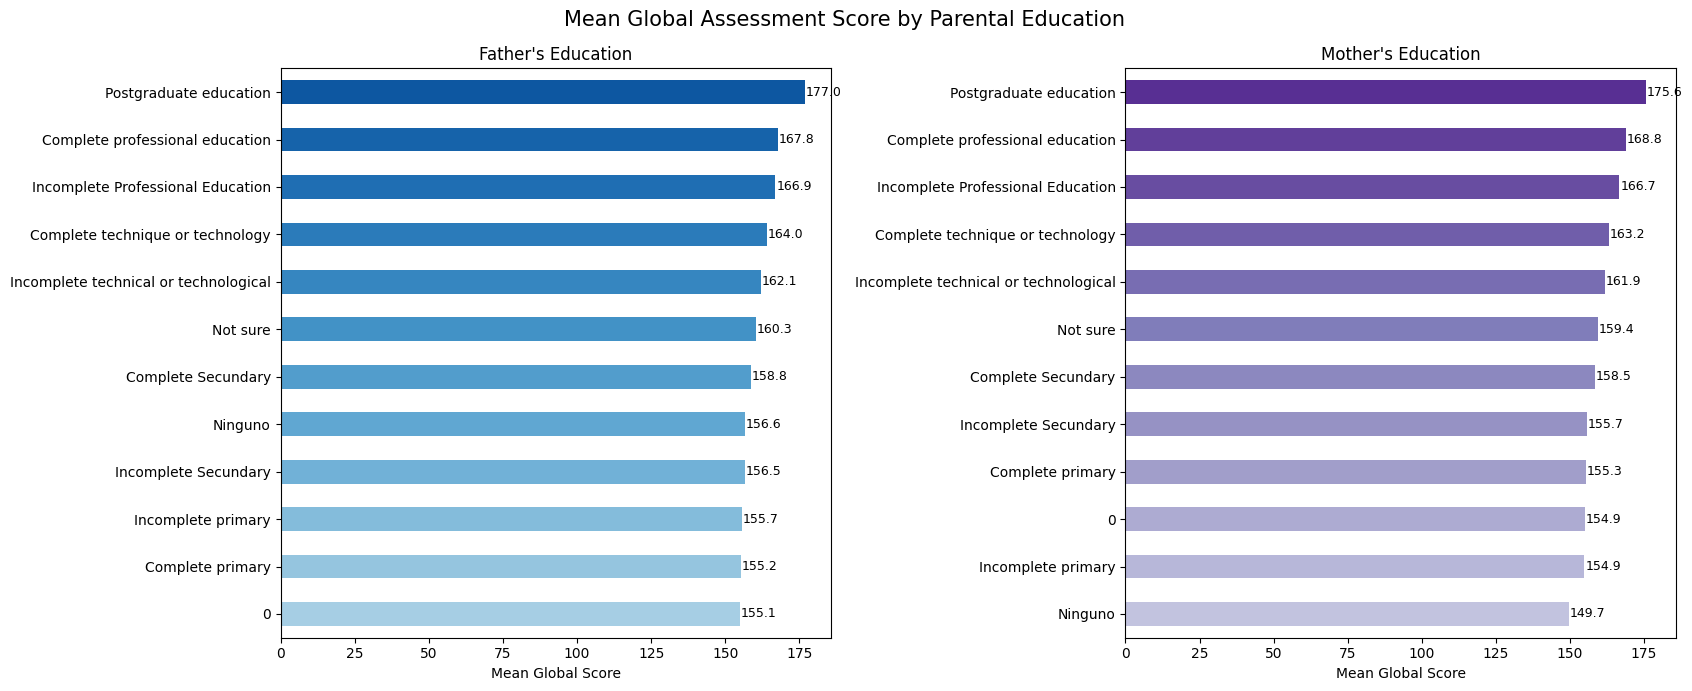

In [118]:
# Compare mean global scores across parental education groups
father_mean = father_edu["mean"].sort_values()
mother_mean = mother_edu["mean"].sort_values()
father_colors = plt.cm.Blues(np.linspace(0.35, 0.85, len(father_mean)))
mother_colors = plt.cm.Purples(np.linspace(0.35, 0.85, len(mother_mean)))

fig, axes = plt.subplots(1, 2, figsize=(17, 7), sharex=True)
father_mean.plot(kind="barh", ax=axes[0], color=father_colors)
mother_mean.plot(kind="barh", ax=axes[1], color=mother_colors)
axes[0].set_title("Father's Education"); axes[1].set_title("Mother's Education")
for ax in axes:
    ax.set_xlabel("Mean Global Score"); ax.set_ylabel("")
for i, value in enumerate(father_mean):
    axes[0].text(value + 0.3, i, f"{value:.1f}", va="center", fontsize=9)
for i, value in enumerate(mother_mean):
    axes[1].text(value + 0.3, i, f"{value:.1f}", va="center", fontsize=9)
plt.suptitle("Mean Global Assessment Score by Parental Education", fontsize=15)
plt.tight_layout()
plt.show()


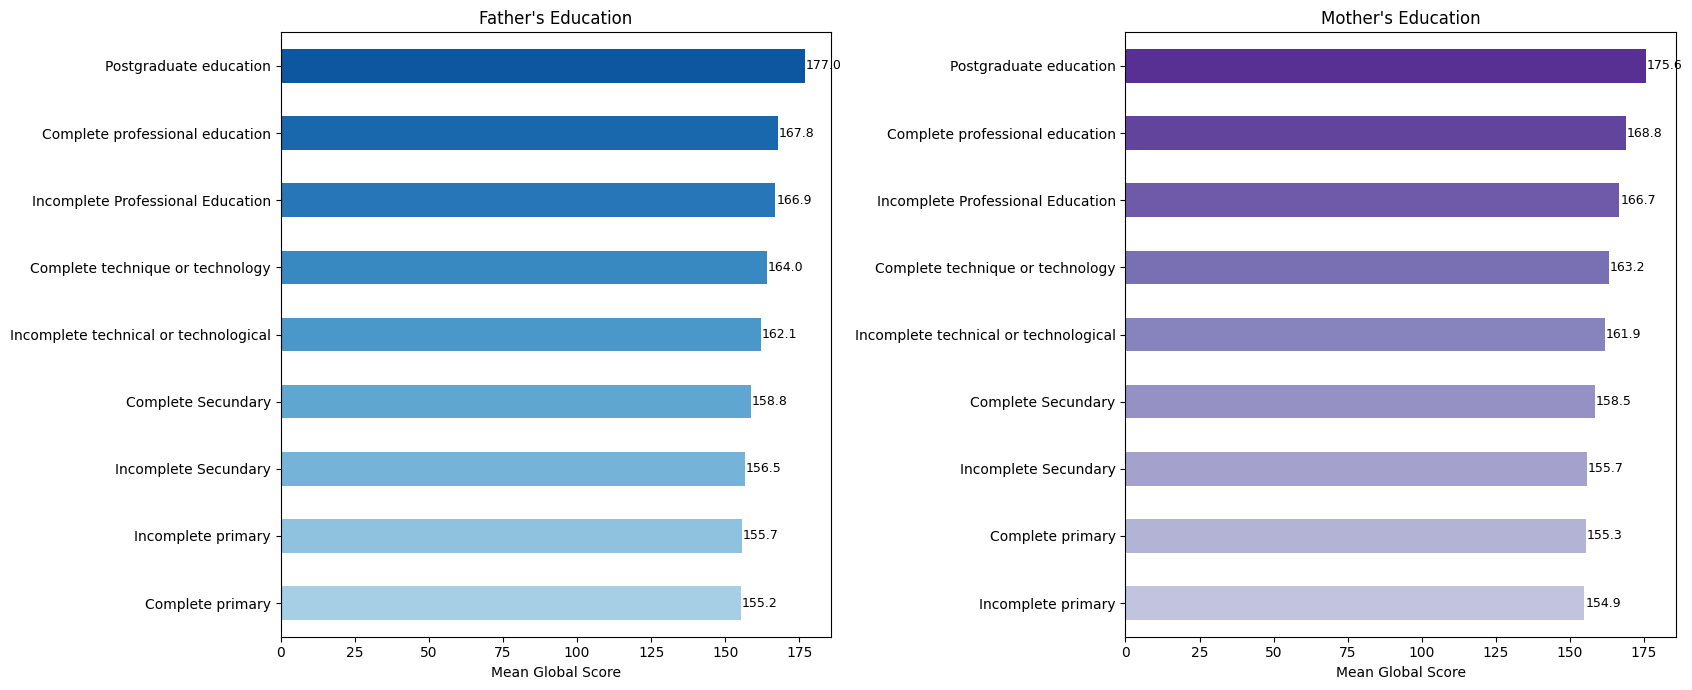

In [119]:
# Compare mean global scores across parental education groups

# Remove ambiguous categories
excluded_categories = ["0", "Not sure", "Ninguno"]

father_edu_plot = father_edu[~father_edu.index.isin(excluded_categories)]
mother_edu_plot = mother_edu[~mother_edu.index.isin(excluded_categories)]

father_mean = father_edu_plot["mean"].sort_values()
mother_mean = mother_edu_plot["mean"].sort_values()

father_colors = plt.cm.Blues(np.linspace(0.35, 0.85, len(father_mean)))
mother_colors = plt.cm.Purples(np.linspace(0.35, 0.85, len(mother_mean)))

fig, axes = plt.subplots(1, 2, figsize=(17, 7), sharex=True)

father_mean.plot(kind="barh", ax=axes[0], color=father_colors)
mother_mean.plot(kind="barh", ax=axes[1], color=mother_colors)

axes[0].set_title("Father's Education")
axes[1].set_title("Mother's Education")

for ax in axes:
    ax.set_xlabel("Mean Global Score")
    ax.set_ylabel("")

for i, value in enumerate(father_mean):
    axes[0].text(value + 0.3, i, f"{value:.1f}", va="center", fontsize=9)

for i, value in enumerate(mother_mean):
    axes[1].text(value + 0.3, i, f"{value:.1f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

In [120]:
# Quantify score differences across selected, clearly defined education levels
print("Father - Primary to Secondary:", round(father_edu.loc["Complete Secundary", "mean"] - father_edu.loc["Complete primary", "mean"], 2))
print("Father - Secondary to Professional:", round(father_edu.loc["Complete professional education", "mean"] - father_edu.loc["Complete Secundary", "mean"], 2))
print("Father - Professional to Postgraduate:", round(father_edu.loc["Postgraduate education", "mean"] - father_edu.loc["Complete professional education", "mean"], 2))
print("Father - Primary to Postgraduate:", round(father_edu.loc["Postgraduate education", "mean"] - father_edu.loc["Complete primary", "mean"], 2))
print("Mother - Primary to Secondary:", round(mother_edu.loc["Complete Secundary", "mean"] - mother_edu.loc["Complete primary", "mean"], 2))
print("Mother - Secondary to Professional:", round(mother_edu.loc["Complete professional education", "mean"] - mother_edu.loc["Complete Secundary", "mean"], 2))
print("Mother - Professional to Postgraduate:", round(mother_edu.loc["Postgraduate education", "mean"] - mother_edu.loc["Complete professional education", "mean"],2))
print("Mother - Primary to Postgraduate:", round(mother_edu.loc["Postgraduate education", "mean"] - mother_edu.loc["Complete primary", "mean"], 2))


Father - Primary to Secondary: 3.59
Father - Secondary to Professional: 8.98
Father - Professional to Postgraduate: 9.22
Father - Primary to Postgraduate: 21.79
Mother - Primary to Secondary: 3.13
Mother - Secondary to Professional: 10.37
Mother - Professional to Postgraduate: 6.79
Mother - Primary to Postgraduate: 20.3


In [121]:
# One-way ANOVA across clearly defined parental education groups
father_analysis = df[~df["EDU_FATHER"].isin(["0", "Not sure", "Ninguno"])].copy()
mother_analysis = df[~df["EDU_MOTHER"].isin(["0", "Not sure", "Ninguno"])].copy()
father_groups = [group["G_SC"].values for name, group in father_analysis.groupby("EDU_FATHER")]
mother_groups = [group["G_SC"].values for name, group in mother_analysis.groupby("EDU_MOTHER")]
father_anova = f_oneway(*father_groups)
mother_anova = f_oneway(*mother_groups)

print("Father's education ANOVA: F =", round(father_anova.statistic, 2), ", p =", father_anova.pvalue)
print("Mother's education ANOVA: F =", round(mother_anova.statistic, 2), ", p =", mother_anova.pvalue)


Father's education ANOVA: F = 119.52 , p = 5.243718863978258e-193
Mother's education ANOVA: F = 118.68 , p = 7.205136526622829e-192


**Interpretation.** Global scores generally increase with parental education. Students whose fathers had postgraduate education scored about **21.79 points** higher on average than students whose fathers had completed primary education; the corresponding difference for mothers was about **20.30 points**. The ANOVA results show statistically significant differences across both father's and mother's education groups (**p < .001**). These results indicate an association between parental education and academic performance, but they do not establish causation.


### 3.2 Socioeconomic Groups and Strata
**Question:** Which groups/strata perform best, and are there differences between them?


In [122]:
# Keep valid strata and summarize global scores
stratum_order = ["Stratum 1", "Stratum 2", "Stratum 3", "Stratum 4", "Stratum 5", "Stratum 6"]
df_stratum = df[df["STRATUM"].isin(stratum_order)].copy()
df_stratum["STRATUM"] = pd.Categorical(df_stratum["STRATUM"], categories=stratum_order, ordered=True)
stratum_summary = df_stratum.groupby("STRATUM", observed=True)["G_SC"].agg(["count", "mean", "median", "std"])
stratum_summary


,count,mean,median,std
STRATUM,,,,
Stratum 1,1709,152.352838,152.0,21.937401
Stratum 2,4029,158.199305,158.0,22.278029
Stratum 3,4045,163.815328,164.0,21.693970
Stratum 4,1578,172.002535,174.0,21.469094
Stratum 5,633,177.387046,179.0,21.543236
Stratum 6,403,181.511166,184.0,21.879401


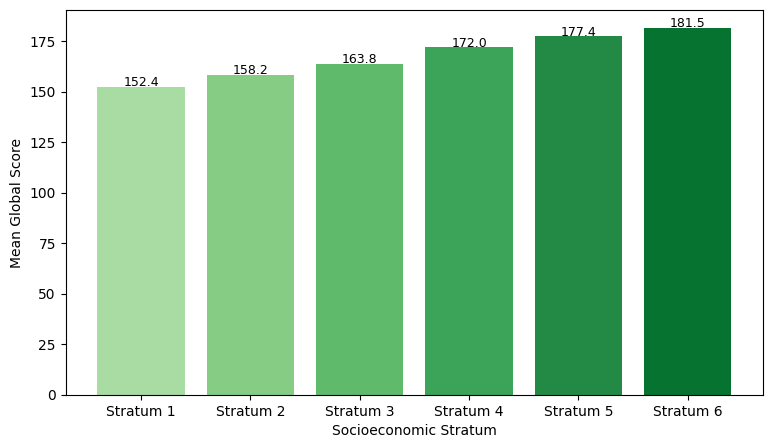

In [123]:
# Mean global score by socioeconomic stratum
stratum_mean = stratum_summary["mean"]
colors = plt.cm.Greens(np.linspace(0.35, 0.85, len(stratum_mean)))
plt.figure(figsize=(9, 5))
plt.bar(stratum_mean.index, stratum_mean.values, color=colors)
plt.xlabel("Socioeconomic Stratum"); plt.ylabel("Mean Global Score")
for i, value in enumerate(stratum_mean.values):
    plt.text(i, value + 0.5, f"{value:.1f}", ha="center", fontsize=9)
plt.show()

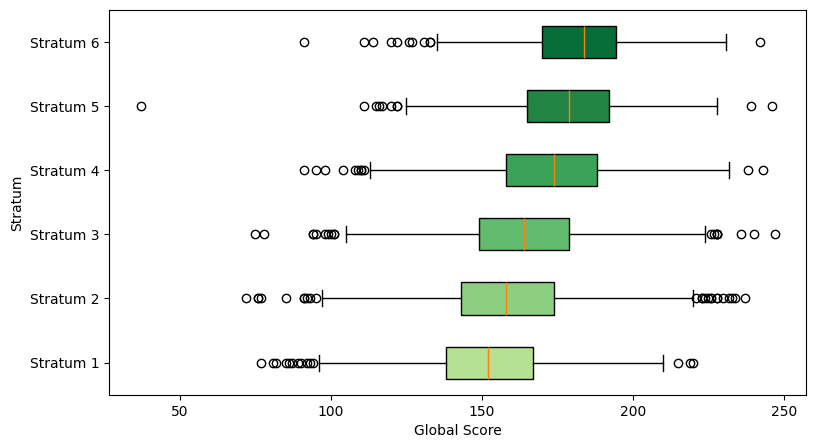

In [124]:
# Distribution of global scores by stratum
stratum_data = [df_stratum[df_stratum["STRATUM"] == group]["G_SC"] for group in stratum_order]
colors = plt.cm.YlGn(np.linspace(0.35, 0.85, len(stratum_order)))
plt.figure(figsize=(9, 5))
box = plt.boxplot(stratum_data, tick_labels=stratum_order, vert=False, patch_artist=True)
for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)
plt.xlabel("Global Score"); plt.ylabel("Stratum")
plt.show()


In [125]:
# Test for overall differences across strata
stratum_groups = [group["G_SC"].values for name, group in df_stratum.groupby("STRATUM", observed=True)]
stratum_anova = f_oneway(*stratum_groups)
print("Stratum ANOVA: F =", round(stratum_anova.statistic, 2), ", p =", stratum_anova.pvalue)
print("Stratum 6 - Stratum 1 mean difference:", round(stratum_summary.loc["Stratum 6", "mean"] - stratum_summary.loc["Stratum 1", "mean"], 2))


Stratum ANOVA: F = 286.06 , p = 1.4255991296541535e-290
Stratum 6 - Stratum 1 mean difference: 29.16


**Stratum interpretation.** Mean global scores rise steadily from Stratum 1 (**152.35**) to Stratum 6 (**181.51**), a difference of about **29.16 points**. The ANOVA result indicates statistically significant differences across strata (p < .001). This suggests a strong relationship between socioeconomic stratum and academic performance.


In [126]:
# Exclude the unclear SISBEN category "0" and summarize the remaining groups
df_sisben = df[df["SISBEN"] != "0"].copy()
sisben_summary = df_sisben.groupby("SISBEN")["G_SC"].agg(["count", "mean", "median", "std"])
sisben_summary.sort_values("mean", ascending=False)


,count,mean,median,std
SISBEN,,,,
It is not classified by the SISBEN,7534,167.469074,169.0,22.478021
Esta clasificada en otro Level del SISBEN,96,166.052083,167.0,22.511457
Level 3,583,160.991424,161.0,21.640175
Level 2,2120,155.893396,156.0,22.268725
Level 1,2057,152.680603,152.0,21.657454


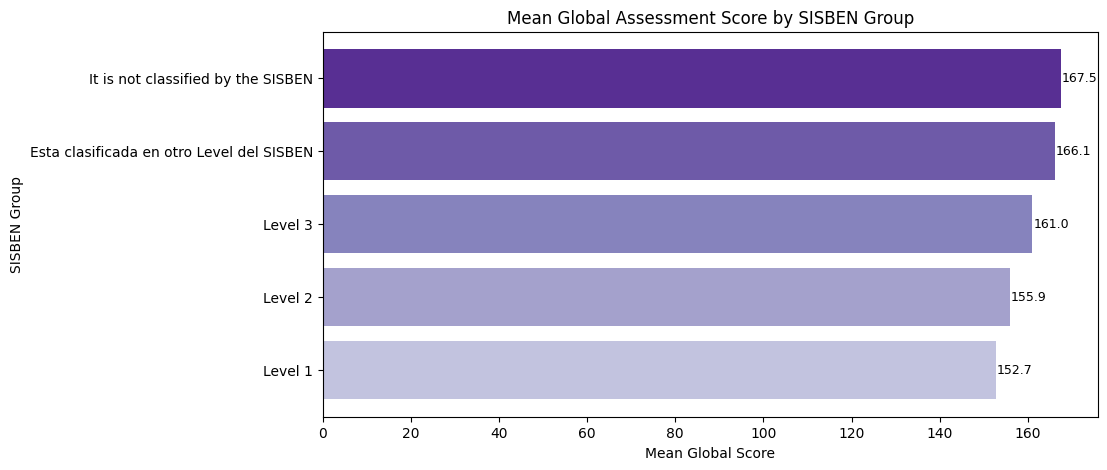

In [127]:
# Mean global score by SISBEN group
sisben_mean = sisben_summary["mean"].sort_values()
colors = plt.cm.Purples(np.linspace(0.35, 0.85, len(sisben_mean)))
plt.figure(figsize=(10, 5))
plt.barh(sisben_mean.index, sisben_mean.values, color=colors)
plt.title("Mean Global Assessment Score by SISBEN Group")
plt.xlabel("Mean Global Score"); plt.ylabel("SISBEN Group")
for i, value in enumerate(sisben_mean.values):
    plt.text(value + 0.3, i, f"{value:.1f}", va="center", fontsize=9)
plt.show()

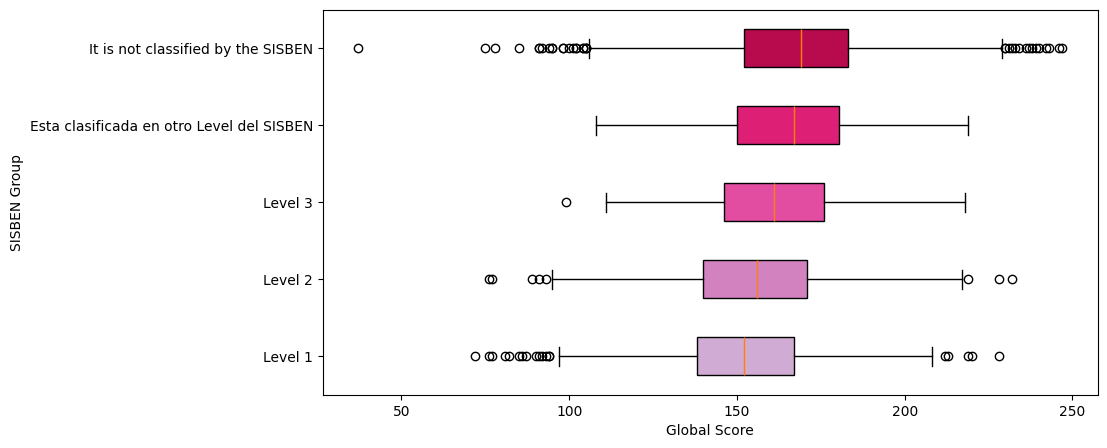

In [128]:
# Distribution of global scores by SISBEN group
sisben_order = sisben_mean.index.tolist()
sisben_data = [df_sisben[df_sisben["SISBEN"] == group]["G_SC"] for group in sisben_order]
colors = plt.cm.PuRd(np.linspace(0.30, 0.80, len(sisben_order)))
plt.figure(figsize=(10, 5))
box = plt.boxplot(sisben_data, tick_labels=sisben_order, vert=False, patch_artist=True)
for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)
plt.xlabel("Global Score"); plt.ylabel("SISBEN Group")
plt.show()

In [129]:
# Test for overall differences across SISBEN groups
sisben_groups = [group["G_SC"].values for name, group in df_sisben.groupby("SISBEN")]
sisben_anova = f_oneway(*sisben_groups)
print("SISBEN ANOVA: F =", round(sisben_anova.statistic, 2), ", p =", sisben_anova.pvalue)
print("Not classified - Level 1 mean difference:", round(sisben_summary.loc["It is not classified by the SISBEN", "mean"] - sisben_summary.loc["Level 1", "mean"], 2))


SISBEN ANOVA: F = 241.39 , p = 5.654167895402367e-200
Not classified - Level 1 mean difference: 14.79


**SISBEN interpretation.** Students who were not classified by SISBEN had the highest mean global score (**167.47**), while Level 1 students had the lowest (**152.68**), a difference of about **14.79 points**. The ANOVA result shows statistically significant differences across SISBEN groups (p < .001). Because the codebook does not define “not classified” as a specific income level, this category should not automatically be interpreted as the highest socioeconomic group.


### 3.3 Gender
**Question:** How does each gender perform in the global assessment?


#### 3.3.1 Gender Difference

In [130]:
# Summarize global score by gender
gender_summary = df.groupby("GENDER")["G_SC"].agg(["count", "mean", "median", "std"])
gender_summary


,count,mean,median,std
GENDER,,,,
F,5043,161.278207,162.0,22.332939
M,7368,163.690825,164.0,23.582616


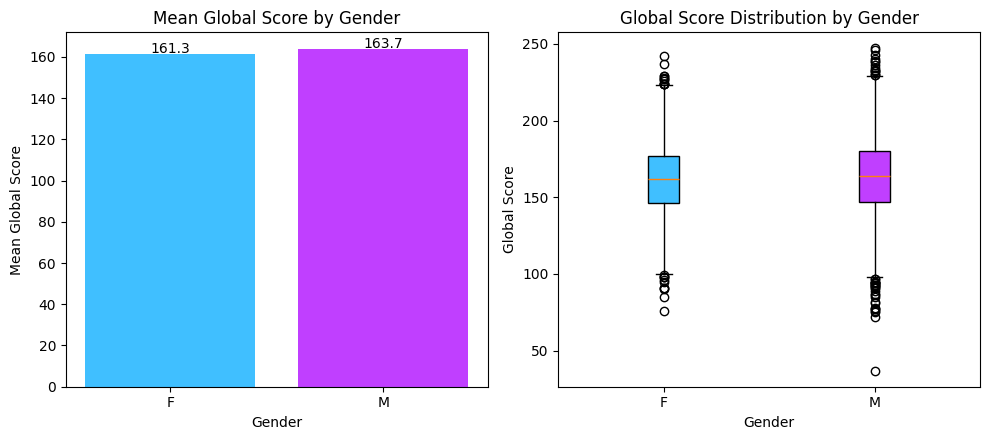

In [131]:
# Compare mean scores and distributions by gender
gender_order = ["F", "M"]
gender_mean = gender_summary.loc[gender_order, "mean"]
gender_data = [df[df["GENDER"] == group]["G_SC"] for group in gender_order]
bar_colors = plt.cm.cool(np.linspace(0.25, 0.75, 2))
box_colors = plt.cm.cool(np.linspace(0.25, 0.75, 2))

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
axes[0].bar(gender_mean.index, gender_mean.values, color=bar_colors)
axes[0].set_title("Mean Global Score by Gender"); axes[0].set_xlabel("Gender"); axes[0].set_ylabel("Mean Global Score")
for i, value in enumerate(gender_mean.values):
    axes[0].text(i, value + 0.5, f"{value:.1f}", ha="center")

box = axes[1].boxplot(gender_data, tick_labels=gender_order, patch_artist=True)
for patch, color in zip(box["boxes"], box_colors):
    patch.set_facecolor(color)
axes[1].set_title("Global Score Distribution by Gender"); axes[1].set_xlabel("Gender"); axes[1].set_ylabel("Global Score")
plt.tight_layout()
plt.show()


In [132]:
# Test for an overall gender difference
female_scores = df[df["GENDER"] == "F"]["G_SC"]
male_scores = df[df["GENDER"] == "M"]["G_SC"]

gender_ttest = ttest_ind(female_scores, male_scores, equal_var=False)

print("Gender t-test:")
print("t-statistic:", round(gender_ttest.statistic, 2))
print("p-value:", gender_ttest.pvalue)


Gender t-test:
t-statistic: -5.78
p-value: 7.785030938251425e-09


**Interpretation.** Male students had a slightly higher mean global score (**163.69**) than female students (**161.28**), a difference of about **2.41 points**. A Welch’s independent-samples t-test indicated that this difference was statistically significant (**t = -5.78, p < .001**). However, the size of the mean difference was relatively modest compared with the differences observed across parental education and socioeconomic groups.


#### 3.3.2 Gender Differences by Subject

In [133]:
# Compare academic subject scores by gender
gender_subjects = ["QR_PRO", "CR_PRO", "CC_PRO", "ENG_PRO", "WC_PRO"]
gender_subject_summary = df.groupby("GENDER")[gender_subjects].mean()
gender_subject_summary

,QR_PRO,CR_PRO,CC_PRO,ENG_PRO,WC_PRO
GENDER,,,,,
F,71.892723,61.338687,58.573865,66.532421,56.618084
M,81.198561,62.788409,59.606270,68.159473,51.708469


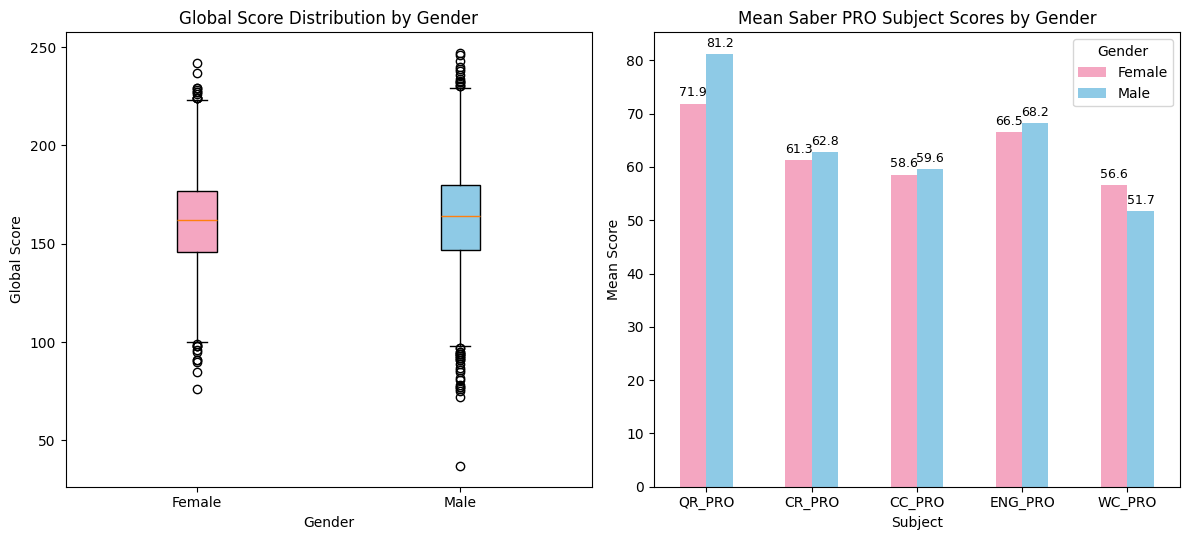

In [134]:
# Compare Global Score distributions and subject scores by gender

gender_order = ["F", "M"]
gender_data = [df[df["GENDER"] == group]["G_SC"] for group in gender_order]

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

# Left: Global Score distribution
box = axes[0].boxplot(
    gender_data,
    tick_labels=["Female", "Male"],
    patch_artist=True
)

box_colors = ["#F4A6C1", "#8ECAE6"]

for patch, color in zip(box["boxes"], box_colors):
    patch.set_facecolor(color)

axes[0].set_title("Global Score Distribution by Gender")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Global Score")

# Right: mean Saber PRO subject scores
gender_subject_summary.T.plot(
    kind="bar",
    ax=axes[1],
    color=["#F4A6C1", "#8ECAE6"]
)

axes[1].set_title("Mean Saber PRO Subject Scores by Gender")
axes[1].set_xlabel("Subject")
axes[1].set_ylabel("Mean Score")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Gender", labels=["Female", "Male"])

for container in axes[1].containers:
    axes[1].bar_label(
        container,
        fmt="%.1f",
        padding=3,
        fontsize=9
    )

plt.tight_layout()
plt.show()

**Interpretation.** The gender differences are not consistent across academic subjects. Male students scored substantially higher in Quantitative Reasoning (**81.20 vs. 71.89**), with a mean difference of about **9.31 points**. In contrast, female students performed better in Written Communication (**56.62 vs. 51.71**), a difference of about **4.91 points**. Male students also had slightly higher mean scores in Critical Reading, Citizen Competencies, and English, but these differences were relatively small, ranging from about **1.03 to 1.63 points**. Welch’s independent-samples t-tests indicated statistically significant gender differences in all five subjects (**p < .05**). However, the largest practical differences were observed in Quantitative Reasoning and Written Communication. These results suggest that the small gender gap in the overall global score may mask more **distinct subject-specific patterns**.

### 3.4 Additional Findings
The following analyses explore academic program, school background, and home technology resources as additional factors that may help inform educational support.


#### 3.4.1 Academic Program


In [135]:
# Summarize global score by academic program
program_summary = df.groupby("ACADEMIC_PROGRAM")["G_SC"].agg(["count", "mean", "median", "std"])
program_summary.sort_values("mean", ascending=False)


,count,mean,median,std
ACADEMIC_PROGRAM,,,,
CHEMICAL ENGINEERING,1000,176.697000,177.0,18.690707
CATASTRAL ENGINEERING AND GEODESY,78,174.602564,176.0,14.953903
ELECTRIC ENGINEERING,278,173.989209,174.5,19.354285
PRODUCTION ENGINEERING,60,172.900000,176.5,20.564656
TOPOGRAPHIC ENGINEERY,42,172.714286,174.0,15.762391
CONTROL ENGINEERING,20,172.150000,170.0,20.911530
TEXTILE ENGINEERING,1,171.000000,171.0,NaN
TRANSPORTATION AND ROAD ENGINEERING,27,167.740741,170.0,10.460889
ELECTRONIC ENGINEERING,849,166.872792,167.0,22.204832


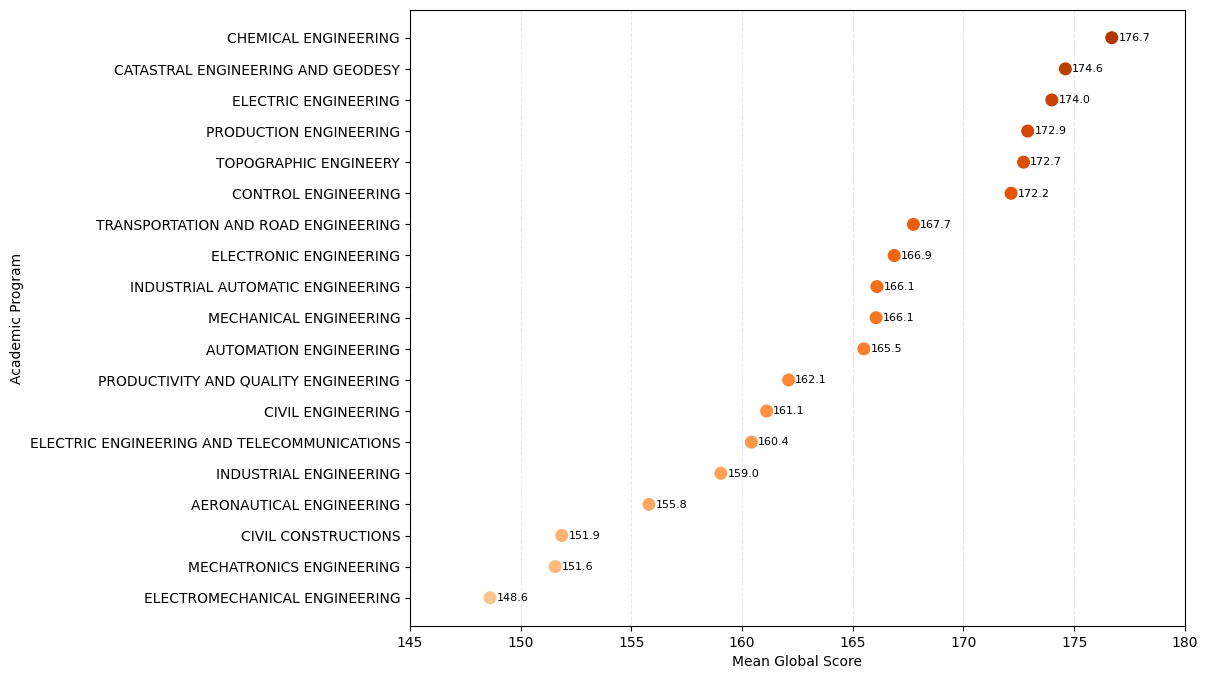

In [136]:
# Plot programs with at least 10 students(I do this because very small groups can produce unstable means, and cannot reflect the real condition)
program_plot = program_summary[program_summary["count"] >= 10].sort_values("mean")
colors = plt.cm.Oranges(np.linspace(0.30, 0.85, len(program_plot)))

plt.figure(figsize=(10, 8))
plt.scatter(program_plot["mean"], program_plot.index, c=colors, s=70)
for i, value in enumerate(program_plot["mean"]):
    plt.text(value + 0.3, i, f"{value:.1f}", va="center", fontsize=8)
plt.xlim(145, 180)
plt.xlabel("Mean Global Score"); plt.ylabel("Academic Program")
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.show()


In [137]:
# ANOVA excluding programs with fewer than 10 students
valid_programs = program_summary[program_summary["count"] >= 10].index
df_program = df[df["ACADEMIC_PROGRAM"].isin(valid_programs)].copy()
program_groups = [group["G_SC"].values for name, group in df_program.groupby("ACADEMIC_PROGRAM")]
program_anova = f_oneway(*program_groups)
print("Academic Program ANOVA: F =", round(program_anova.statistic, 2), ", p =", program_anova.pvalue)


Academic Program ANOVA: F = 42.3 , p = 2.5063572396250267e-145


**Interpretation.** Academic performance varies across engineering programs. Among programs with at least 10 students, Chemical Engineering had the highest mean global score (**176.70**), while Electromechanical Engineering had the lowest (**148.62**). The difference should be interpreted cautiously because program sample sizes vary substantially. Programs with only one student were excluded from the plotted comparison and ANOVA because their means are not reliable group estimates.


#### 3.4.2 School Background


In [138]:
# Summarize school nature and school type
school_nat_summary = df.groupby("SCHOOL_NAT")["G_SC"].agg(["count", "mean", "median", "std"])
school_type_analysis = df[df["SCHOOL_TYPE"] != "Not apply"].copy()
school_type_summary = school_type_analysis.groupby("SCHOOL_TYPE")["G_SC"].agg(["count", "mean", "median", "std"])
print("School nature:")
display(school_nat_summary)
print("School type:")
display(school_type_summary.sort_values("mean", ascending=False))


School nature:


,count,mean,median,std
SCHOOL_NAT,,,,
PRIVATE,6565,168.215842,170.0,22.823659
PUBLIC,5846,156.528053,157.0,21.838175


School type:


,count,mean,median,std
SCHOOL_TYPE,,,,
ACADEMIC,7834,165.851800,167.0,23.254263
TECHNICAL/ACADEMIC,3513,157.485056,157.0,21.844941
TECHNICAL,1059,156.864023,157.0,21.832634


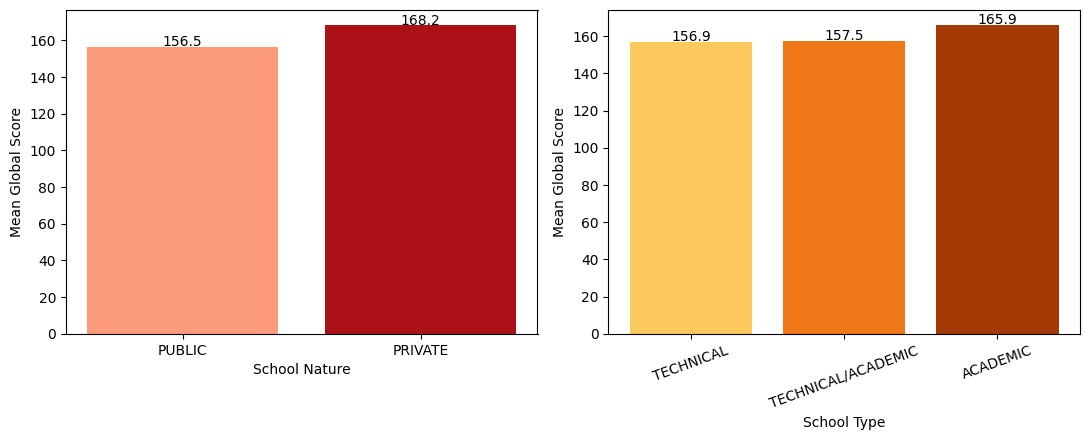

In [139]:
# Compare school background groups
school_nat_mean = school_nat_summary["mean"].sort_values()
school_type_mean = school_type_summary["mean"].sort_values()
nat_colors = plt.cm.Reds(np.linspace(0.35, 0.85, len(school_nat_mean)))
type_colors = plt.cm.YlOrBr(np.linspace(0.35, 0.85, len(school_type_mean)))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].bar(school_nat_mean.index, school_nat_mean.values, color=nat_colors)
axes[0].set_xlabel("School Nature"); axes[0].set_ylabel("Mean Global Score")
for i, value in enumerate(school_nat_mean.values):
    axes[0].text(i, value + 0.5, f"{value:.1f}", ha="center")

axes[1].bar(school_type_mean.index, school_type_mean.values, color=type_colors)
axes[1].set_xlabel("School Type"); axes[1].set_ylabel("Mean Global Score")
axes[1].tick_params(axis="x", rotation=20)
for i, value in enumerate(school_type_mean.values):
    axes[1].text(i, value + 0.5, f"{value:.1f}", ha="center")
plt.tight_layout()
plt.show()


In [140]:
# Test for differences by school nature and school type
private_scores = df[df["SCHOOL_NAT"] == "PRIVATE"]["G_SC"]
public_scores = df[df["SCHOOL_NAT"] == "PUBLIC"]["G_SC"]

school_nat_ttest = ttest_ind(private_scores, public_scores, equal_var=False)
print("School Nature t-test:")
print("t-statistic:", round(school_nat_ttest.statistic, 2))
print("p-value:", school_nat_ttest.pvalue)

school_type_groups = [group["G_SC"].values for name, group in school_type_analysis.groupby("SCHOOL_TYPE")]
school_type_anova = f_oneway(*school_type_groups)
print("School Type ANOVA: F =", round(school_type_anova.statistic, 2), ", p =", school_type_anova.pvalue)

School Nature t-test:
t-statistic: 29.14
p-value: 1.5274471564932437e-180
School Type ANOVA: F = 202.42 , p = 3.1122906005052578e-87


**Interpretation.** Students from private schools had a higher mean global score (**168.22**) than students from public schools (**156.53**), a difference of about **11.69 points**. A Welch’s independent-samples t-test indicated that this difference was statistically significant (**p < .001**). Mean global scores also differed across school types, and the one-way ANOVA indicated statistically significant overall differences among these groups (**p < .001**). These findings show associations between school background and later academic performance, but they do not establish causal effects.


#### 3.4.3 Home Resources and Technology Access


In [141]:
# Summarize internet and computer access
internet_summary = df.groupby("INTERNET")["G_SC"].agg(["count", "mean", "median", "std"])
computer_summary = df.groupby("COMPUTER")["G_SC"].agg(["count", "mean", "median", "std"])
print("Internet access:")
display(internet_summary)
print("Computer access:")
display(computer_summary)


Internet access:


,count,mean,median,std
INTERNET,,,,
No,2659,154.616397,154.0,22.206930
Yes,9752,164.917453,166.0,22.862456


Computer access:


,count,mean,median,std
COMPUTER,,,,
No,2237,155.952615,156.0,21.860398
Yes,10174,164.196383,165.0,23.116346


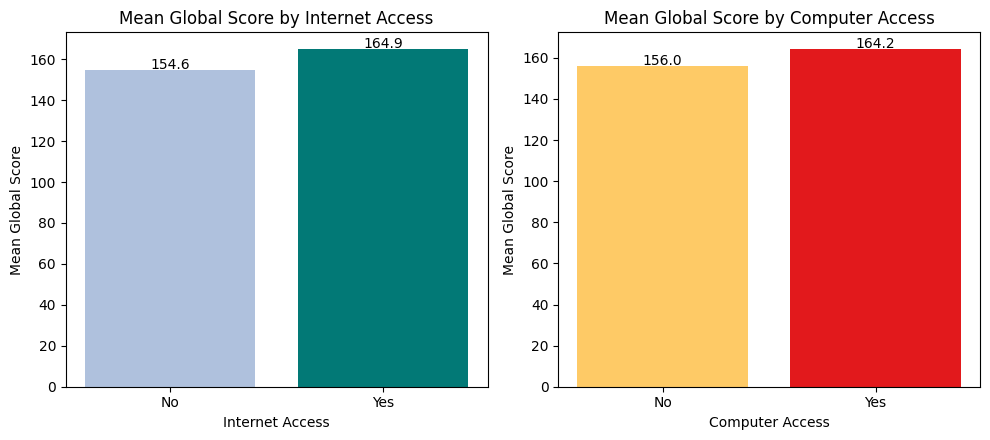

In [142]:
# Compare mean global scores by internet and computer access
internet_mean = internet_summary["mean"].sort_values()
computer_mean = computer_summary["mean"].sort_values()
internet_colors = plt.cm.PuBuGn(np.linspace(0.35, 0.80, len(internet_mean)))
computer_colors = plt.cm.YlOrRd(np.linspace(0.30, 0.75, len(computer_mean)))

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
axes[0].bar(internet_mean.index, internet_mean.values, color=internet_colors)
axes[0].set_title("Mean Global Score by Internet Access"); axes[0].set_xlabel("Internet Access"); axes[0].set_ylabel("Mean Global Score")
for i, value in enumerate(internet_mean.values):
    axes[0].text(i, value + 0.5, f"{value:.1f}", ha="center")

axes[1].bar(computer_mean.index, computer_mean.values, color=computer_colors)
axes[1].set_title("Mean Global Score by Computer Access"); axes[1].set_xlabel("Computer Access"); axes[1].set_ylabel("Mean Global Score")
for i, value in enumerate(computer_mean.values):
    axes[1].text(i, value + 0.5, f"{value:.1f}", ha="center")
plt.tight_layout()
plt.show()


In [143]:
# Test for differences by internet and computer access
internet_yes = df[df["INTERNET"] == "Yes"]["G_SC"]
internet_no = df[df["INTERNET"] == "No"]["G_SC"]
internet_ttest = ttest_ind(
    internet_yes,
    internet_no,
    equal_var=False
)

print("Internet Access t-test:")
print("t-statistic:", round(internet_ttest.statistic, 2))
print("p-value:", internet_ttest.pvalue)

Internet Access t-test:
t-statistic: 21.07
p-value: 7.123238974484883e-94


In [144]:
computer_yes = df[df["COMPUTER"] == "Yes"]["G_SC"]
computer_no = df[df["COMPUTER"] == "No"]["G_SC"]
computer_ttest = ttest_ind(computer_yes, computer_no, equal_var=False)

print("Computer Access t-test:")
print("t-statistic:", round(computer_ttest.statistic, 2))
print("p-value:", computer_ttest.pvalue)

Computer Access t-test:
t-statistic: 15.98
p-value: 1.713740480845964e-55


**Interpretation.** Students with internet access had a mean global score of **164.92**, compared with **154.62** for students without internet access, a difference of about **10.30 points**. Students with a computer also scored higher on average (**164.20** vs. **155.95**), a difference of about **8.24 points**. Both differences are statistically significant (p < .001), although these descriptive comparisons do not show that technology access itself causes higher performance.


## 4. Academic Performance Across Educational Stages

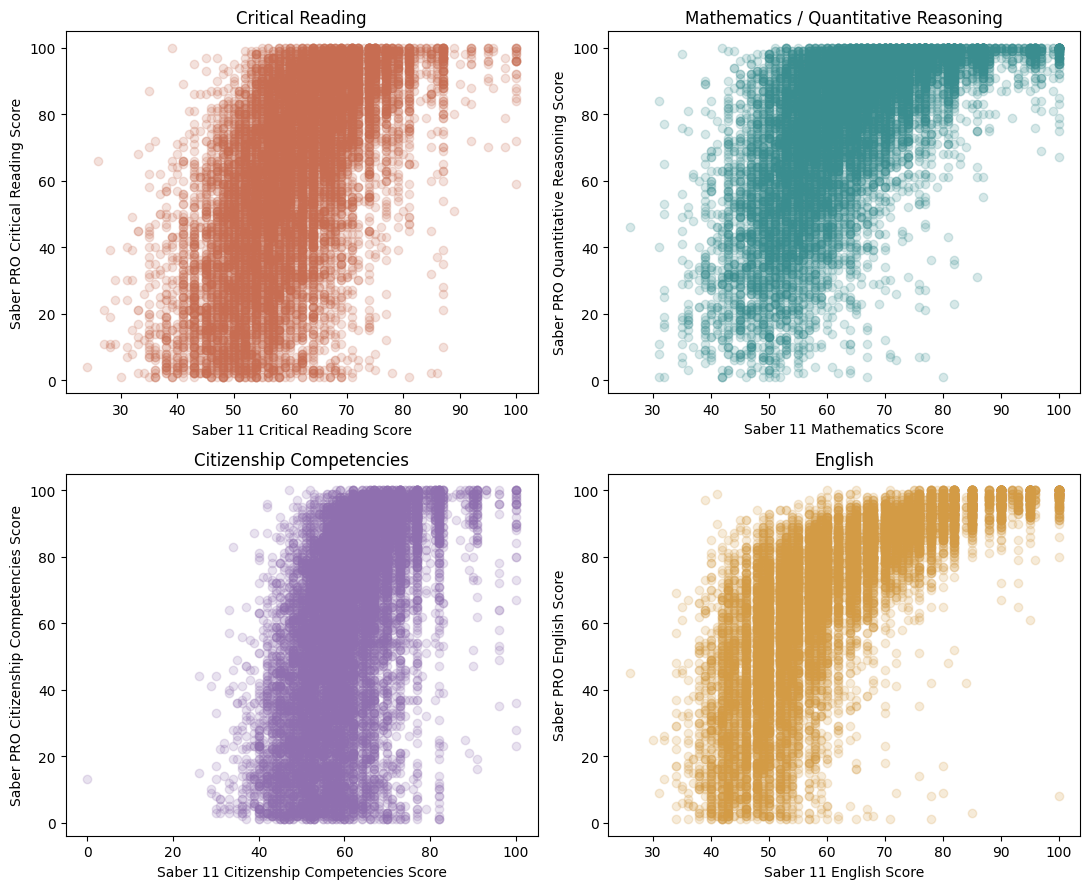

In [145]:
# Compare academic performance across the two educational stages
fig, axes = plt.subplots(2, 2, figsize=(11, 9))

# Critical Reading
axes[0, 0].scatter(df["CR_S11"], df["CR_PRO"], alpha=0.20, color="#C76D52")
axes[0, 0].set_title("Critical Reading")
axes[0, 0].set_xlabel("Saber 11 Critical Reading Score")
axes[0, 0].set_ylabel("Saber PRO Critical Reading Score")

# Mathematics / Quantitative Reasoning
axes[0, 1].scatter(df["MAT_S11"], df["QR_PRO"], alpha=0.20, color="#3A8D8F")
axes[0, 1].set_title("Mathematics / Quantitative Reasoning")
axes[0, 1].set_xlabel("Saber 11 Mathematics Score")
axes[0, 1].set_ylabel("Saber PRO Quantitative Reasoning Score")

# Citizenship Competencies
axes[1, 0].scatter(df["CC_S11"], df["CC_PRO"], alpha=0.20, color="#8F6FAF")
axes[1, 0].set_title("Citizenship Competencies")
axes[1, 0].set_xlabel("Saber 11 Citizenship Competencies Score")
axes[1, 0].set_ylabel("Saber PRO Citizenship Competencies Score")

# English
axes[1, 1].scatter(df["ENG_S11"], df["ENG_PRO"], alpha=0.20, color="#D39B45")
axes[1, 1].set_title("English")
axes[1, 1].set_xlabel("Saber 11 English Score")
axes[1, 1].set_ylabel("Saber PRO English Score")

plt.tight_layout()
plt.show()

**Interpretation.** The scatterplots suggest **a positive relationship between students' performance at the end of high school and at the end of university**. However, substantial variation remains among students with similar high-school scores. Therefore, these figures show an association between earlier and later academic performance, rather than directly measuring academic growth or value added.

## 5. Summary of Findings

Parental education and socioeconomic stratum show some of the largest score differences in the analysis. School background, academic program, SISBEN classification, and access to internet or computers are also associated with Global Scores. The overall gender difference is small, although the subject-level comparisons show larger differences in Quantitative Reasoning and Written Communication. The scatterplots also suggest continuity between high-school and university performance.
